In [1]:
# import os; os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.2' # NOTE: jax preallocates GPU (default 75%)


import jax.numpy as jnp
import numpy as np
from numba import vectorize, njit, prange, jit
import jax.scipy.special as jsp
import numba
import math
from jax import jit

from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import jax
from scipy.interpolate import CubicSpline as CS
from functools import partial
import jax.random as jrandom


In [2]:
jax.devices()

[CpuDevice(id=0)]

In [3]:
from jaxili.inference import NPE
from jaxili.model import ConditionalRealNVP,MixtureDensityNetwork

In [4]:
import HOD_NRV
halo = pd.read_parquet('/Users/ler13nrv/Documents/halo_catalogue.parquet')

In [5]:
b = np.column_stack([halo.b_x,halo.b_y,halo.b_z])
a = np.column_stack([halo.a_x,halo.a_y,halo.a_z])
b = b/np.linalg.norm(b,axis=1)[:,None]
a = a/np.linalg.norm(a,axis=1)[:,None]
c = np.cross(b,a)

In [6]:
cosmo_params = {'flat': True, 'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8': 0.8159, 'ns': 0.9667}
HOD_model =HOD_NRV.HOD_models.Occupation("ELG_GHOD",cosmo_params,z_snap=1.03)
Ac = 1.
Mmin = 12.
sig_M = 0.6
M1 = 13.
As = 1.
alpha = 0.6
kappa = 0.8
logM = jnp.geomspace(10.6,15,1000)
dict_params = {'kappa':kappa,'Ac':Ac,'As':As,'Mmin':Mmin, 'sig_M':sig_M,'M1':M1,'alpha':alpha}
HOD_model.set_params(dict_params)



In [38]:
Rvir = jnp.array(halo.rvir[0:20000].values)
Rs = jnp.array(halo.rs_klypin[0:20000].values)
Ns = jnp.array(np.random.randint(1,25,20000))
c = Rvir/Rs
centers = jnp.stack([halo.x.values,halo.y.values,halo.z.values],axis=1)[0:20000]
velocities = jnp.stack([halo.vx.values,halo.vy.values,halo.vz.values],axis=1)[0:20000]
vrms = halo.vrms.values[0:1000]
N = int(jnp.sum(Ns))

In [39]:
Ns

Array([19, 18, 11, ...,  6,  7,  2], dtype=int32)

In [8]:
key = jrandom.PRNGKey(0)
key, key_r,key_theta,key_phi = jrandom.split(key,num=4)

In [9]:

import jax.scipy.interpolate as jinterp
# interpolate = RegularGridInterpolator(points, values, method='linear')

    
@jit
def NFW_CDF(r,rs,c):
    CDF = (jnp.log(1+r/rs) - (r/rs)/(1+r/rs))/(jnp.log(1+c) - c/(1+c))
    return CDF

@partial(jit,static_argnames='num_point')
def inverse_CDF(c,rs,Rvir,key,num_point):
    r  = jnp.logspace(-2,jnp.log10(Rvir),num_point)
    key,subkey = jrandom.split(key)
    CDF = NFW_CDF(r,rs,c)
    uniform_random = jrandom.uniform(subkey, shape=(num_point,))
    inverse_cdf = jnp.interp(uniform_random, CDF, r)
    return inverse_cdf

@partial(jit,static_argnames='num_point')
def nfw_inv_cdf_sampler(u, Rs, Rvir, key, num_point):
    r_vals = jnp.linspace(1e-3, Rvir, 1000)
    x = r_vals / Rs
    m_vals = jnp.log(1 + x) - x / (1 + x)
    CDF = m_vals / m_vals[-1]
    r_samples = jnp.interp(u,CDF, r_vals)
    return r_samples

In [10]:
@partial(jit,static_argnames='n')
def random_uniform_jax(key,n,a=0,b=1):
    key, subkey = jrandom.split(key)
    result = jrandom.uniform(subkey, (n,),minval=a,maxval=b)
    return result

In [76]:
import jax.numpy as jnp
from jax import random

key = random.PRNGKey(0)
# num_halos = 10
num_halos = len(Rvir)
# N_s = random.randint(key, shape=(num_halos,), minval=1, maxval=21)  # (10,) values from 1 to 20

# # Simulate Rvir and concentration
# Rvir = random.uniform(key, shape=(num_halos,), minval=0.1, maxval=3.0)
# c = random.uniform(key, shape=(num_halos,), minval=1.0, maxval=10.0)

# Prepare u_samples padded to shape (num_halos, max_N_s)
max_N_s = int(Ns.max())
u_samples_padded = jnp.zeros((num_halos, max_N_s))
mask = jnp.zeros((num_halos, max_N_s), dtype=bool)

subkeys = random.split(key, num_halos)
for i in range(num_halos):
    n = N_s[i]
    u = random.uniform(subkeys[i], shape=(n,), minval=0.0, maxval=1.0)
    u_samples_padded = u_samples_padded.at[i, :n].set(u)
    mask = mask.at[i, :n].set(True)

In [94]:
#@partial(jit,static_argnames='size')
def random_uniform_jax(key,shape,a=0,b=1):
    result = jrandom.uniform(subkey,shape,minval=a,maxval=b)
    return result

In [91]:
%%time
random_uniform_jax(subkey,(num_halos,max_N_s))

CPU times: user 477 μs, sys: 300 μs, total: 777 μs
Wall time: 520 μs


Array([[0.08260381, 0.7807871 , 0.93827987, ..., 0.15393794, 0.5572294 ,
        0.23507726],
       [0.85410535, 0.18864048, 0.7751943 , ..., 0.8379959 , 0.8178091 ,
        0.31037974],
       [0.23638272, 0.16126037, 0.40788758, ..., 0.32289994, 0.25175714,
        0.6331458 ],
       ...,
       [0.25451434, 0.2873708 , 0.41794086, ..., 0.67255354, 0.99669313,
        0.42728436],
       [0.27380097, 0.8335614 , 0.6791208 , ..., 0.42160475, 0.798293  ,
        0.17746556],
       [0.6946461 , 0.0819211 , 0.45083106, ..., 0.5139941 , 0.3597039 ,
        0.9784945 ]], dtype=float32)

In [105]:
%%time
key, subkey = random.split(key)
u_samples_all = random_uniform_jax(subkey,(num_halos, max_N_s))

# Create the mask: True where index < N_s[i]
indices = jnp.arange(max_N_s)
mask = indices[None, :] < Ns[:, None]

# Zero out invalid entries (optional, only if needed; could also just use the mask)
u_samples_padded = jnp.where(mask, u_samples_all, 0.0)

CPU times: user 2.29 ms, sys: 3.7 ms, total: 5.99 ms
Wall time: 2.01 ms


In [57]:
Ns

Array([19, 18, 11, ...,  6,  7,  2], dtype=int32)

In [45]:
def single_eval(u, Rvir_i, rs_i, c_i):
    r_grid = jnp.geomspace(0.001, Rvir_i, 1000)
    cdf = NFW_CDF(r_grid, rs_i, c_i)
    return jnp.interp(u, cdf, r_grid)

@jax.jit
def batch_inverse_cdf(u_samples, Rvir, c, mask):
    rs = Rvir / c

    # vmap across satellites within each halo, then halos
    batched_eval = jax.vmap(
        jax.vmap(single_eval, in_axes=(0, None, None, None)),  # over satellites
        in_axes=(0, 0, 0, 0)  # over halos
    )
    
    r_samples = batched_eval(u_samples, Rvir, rs, c)

    # Optionally mask padded outputs
    r_samples = jnp.where(mask, r_samples, jnp.nan)
    return r_samples

In [47]:
%%time
batch_inverse_cdf(u_samples_padded, Rvir, c, mask)

CPU times: user 1.39 ms, sys: 2.52 ms, total: 3.9 ms
Wall time: 927 μs


Array([[157.31454  ,  28.232195 ,  34.117912 , ...,         nan,
                nan,         nan],
       [  2.2707267,         nan,         nan, ...,         nan,
                nan,         nan],
       [ 95.3346   ,  97.04338  ,  27.671968 , ...,         nan,
                nan,         nan],
       ...,
       [ 70.03406  ,  94.3358   ,  64.402664 , ...,         nan,
                nan,         nan],
       [ 68.80748  ,  52.64857  ,  88.22181  , ...,         nan,
                nan,         nan],
       [ 16.215557 ,  19.765276 ,  94.69264  , ...,         nan,
                nan,         nan]], dtype=float32)

In [11]:
@partial(jit,static_argnames=["N"])
def single_halo(r_grid,Rvir, Rs, N):
    key = jrandom.key(np.random.randint(0,int(2**32)))
    x = r_grid / Rs
    m_vals = jnp.log(1 + x) - x / (1 + x)
    CDF = m_vals / m_vals[-1]
    u = random_uniform_jax(key,N)
    r_samples = jnp.interp(u,CDF, r_grid)
    return r_samples


#@partial(jit, static_argnames=["num_points"])
def batched_inverse_cdf(Rvir_array, Rs_array,N, num_points=1024):
    r_grid = jnp.logspace(-3, jnp.log10(Rvir_array), num_points)
    return vmap(single_halo)(r_grid,Rvir_array, Rs_array,N)

In [12]:
N = jnp.array(np.random.randint(1,100,size=len(Rvir)))
result=batched_inverse_cdf(Rvir,Rs,Ns)

ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * most axes (3 of them) had size 20000, e.g. axis 0 of argument Rvir of type float32[20000];
  * one axis had size 1024: axis 0 of argument r_grid of type float32[1024,20000]

In [15]:
grid_size=80

In [16]:
@partial(jit, static_argnames=['grid_size', 'cdf_points'])
def create_nfw_emulator(grid_size=80, cdf_points=1000):
    """
    Create an emulator for NFW profiles based on a grid of parameters
    
    Args:
        grid_size: Number of grid points for each parameter
        cdf_points: Number of points to use for the CDF evaluation
        
    Returns:
        Interpolator function that can quickly evaluate inverse CDF
    """
    # Create parameter grids
    u_grid = jnp.linspace(0.001, 0.999, 300)  # Uniform random values
    c_grid = jnp.geomspace(1, 30, grid_size)        # Concentration values from 1 to ~31.6
    Rvir_grid = jnp.geomspace(0.05,4, grid_size)      # Virial radii from 0.1 to 100
    # Create meshgrid for all parameter combinations
    u_mesh, c_mesh, Rvir_mesh = jnp.meshgrid(u_grid, c_grid, Rvir_grid, indexing='ij')
    
    # Compute rs from concentration and Rvir
    rs_mesh = Rvir_mesh / c_mesh
    
    # Compute r values (result of inverse CDF) for each parameter combination
    # We need to compute the CDF at many radii and then interpolate
    def compute_single_inverse_cdf(c, rs, Rvir, u):
        r_values = jnp.geomspace(0.001, Rvir, cdf_points)
        cdf_values = NFW_CDF(r_values, rs, c)
        return jnp.interp(u, cdf_values, r_values)
    
    # Use vmap to vectorize over all parameter combinations
    compute_batch = jax.vmap(jax.vmap(jax.vmap(compute_single_inverse_cdf)))
    r_values = compute_batch(c_mesh, rs_mesh, Rvir_mesh, u_mesh)
    
    return r_values

In [17]:
c_grid = jnp.geomspace(1, 30, grid_size)        # Concentration values from 1 to ~31.6
Rvir_grid = jnp.geomspace(0.05,4, grid_size) 
r_grid = jnp.logspace(-3, jnp.log10(Rvir_grid.max()), 10000)
rs_grid = Rvir_grid/c_grid
u_grid = jnp.linspace(0.001, 0.999, 300)  # Uniform random values



In [18]:
u_data = jnp.repeat(u_grid, grid_size * grid_size)
c_data = jnp.tile(jnp.repeat(c_grid, grid_size), 300)
Rvir_data = jnp.tile(jnp.tile(Rvir_grid, grid_size), 300)



In [19]:
data_vector = np.column_stack([u_data,c_data,Rvir_data])

In [20]:
result=create_nfw_emulator(grid_size)

In [24]:
hparams = {'n_in':1, 'n_cond':3,'layers':[50,50,50],'activation':jax.nn.relu, 'n_components':2}
inference = NPE(model_class=MixtureDensityNetwork,model_hparams=hparams)

In [25]:
inference = inference.append_simulations(result.flatten()[:,None],data_vector)

[!] Inputs are valid.
[!] Appending 1920000 simulations to the dataset.
[!] Dataset split into training, validation and test sets.
[!] Training set: 1344000 simulations.
[!] Validation set: 383999 simulations.
[!] Test set: 192001 simulations.


In [26]:
CHECKPOINT_PATH = "." 
import os
CHECKPOINT_PATH = os.path.abspath(CHECKPOINT_PATH)

metrics,density_estimator = inference.train(training_batch_size=512,num_epochs=500,learning_rate=1e-4,checkpoint_path=CHECKPOINT_PATH)

Distribution subclass DistributionFromTFP inherits `_parameter_properties from its parent (MultivariateNormalTriL)
while also redefining `__init__`. The inherited annotations cover the following
parameters: dict_keys(['loc', 'scale_tril']). It is likely that these do not match the subclass parameters.
This may lead to errors when computing batch shapes, slicing into batch
dimensions, calling `.copy()`, flattening the distribution as a CompositeTensor
(e.g., when it is passed or returned from a `tf.function`), and possibly other
cases. The recommended pattern for distribution subclasses is to define a new
`_parameter_properties` method with the subclass parameters, and to store the
corresponding parameter values as `self._parameters` in `__init__`, after
calling the superclass constructor:

```
class MySubclass(tfd.SomeDistribution):

  def __init__(self, param_a, param_b):
    parameters = dict(locals())
    # ... do subclass initialization ...
    super(MySubclass, self).__init__(**ba

[!] Creating DataLoaders with batch_size 512.
[!] Building the neural network.
[!] Creating the Trainer module.

                         NDE_w_Standardization Summary                          
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ path          ┃ module        ┃ inputs        ┃ outputs       ┃ params       ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│               │ NDE_w_Standa… │ -             │ float32[1]    │              │
│               │               │ float32[1,1]  │               │              │
│               │               │ -             │               │              │
│               │               │ float32[1,3]  │               │              │
├───────────────┼───────────────┼───────────────┼───────────────┼──────────────┤
│ embedding_net │ Sequential    │ float32[1,3]  │ float32[1,3]  │              │
├───────────────┼───────────────┼───────────────┼───────────────┼────────────

Epochs: Val loss nan/ Best val loss -5.126:  33%|███▎      | 166/500 [03:58<07:59,  1.44s/it]   


Neural network training stopped after 167 epochs.
Early stopping with best validation metric: -5.125920295715332
Best model saved at epoch 146
Early stopping parameters: min_delta=0.001, patience=20
[!] Training loss: -4.947694301605225
[!] Validation loss: -5.125920295715332
[!] Test loss: -5.130916118621826


In [22]:
result.shape

(300, 80, 80)

In [50]:
elements = result[:, 40, 40]
profile = r_grid/rs_grid[40]/((1+r_grid/rs_grid[40])**2)

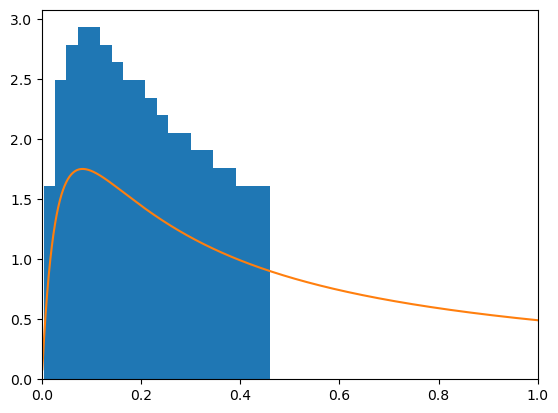

In [52]:
plt.xlim(0,1)
plt.hist(elements,bins=20,density=True)
plt.plot(r_grid,7*profile)

In [ ]:
    # Create parameter grids
    u_grid = jnp.linspace(0.001, 0.999, 200)  # Uniform random values
    c_grid = jnp.geomspace(1, 30, 60)        # Concentration values from 1 to ~31.6
    Rvir_grid = jnp.geomspace(0.05,4, 60)      # Virial radii from 0.1 to 100
    # Create meshgrid for all parameter combinations
    u_mesh, c_mesh, Rvir_mesh = jnp.meshgrid(u_grid, c_grid, Rvir_grid, indexing='ij')

In [ ]:
def generate_inverse_cdf_data(num_points=1024, num_u=512):
    r_grid = jnp.logspace(-2, jnp.log10(2.0), num_points)
    u_grid = jnp.linspace(0.001, 0.999, num_u)
    samples = []

    Rvir_vals = jnp.linspace(0.1, 2.0, 20)
    c_vals = jnp.linspace(3.0, 20.0, 20)

    for Rvir in Rvir_vals:
        for c in c_vals:
            Rs = Rvir / c
            CDF = NFW_CDF(r_grid, Rs, c)
            r_samples = jnp.interp(u_grid, CDF, r_grid)
            for i in range(num_u):
                samples.append([u_grid[i], Rvir, c, r_samples[i]])
    return jnp.array(samples)

In [ ]:
    r_grid = jnp.logspace(-2, jnp.log10(2.0), num_points)
    u_grid = jnp.linspace(0.001, 0.999, num_u)
    samples = []

    Rvir_vals = jnp.linspace(0.1, 2.0, 20)
    c_vals = jnp.linspace(3.0, 20.0, 20)

In [ ]:
r_grid = jnp.logspace(-3, jnp.log10(4.0), 512)
u_grid = jnp.linspace(1e-4, 1, 1024)
samples = []

Rvir_vals = jnp.linspace(1e-2, 2.0, 128)
c_vals = jnp.linspace(1.0, 20.0, 128)

In [ ]:
%%time
result=batched_inverse_cdf(Rvir,Rs,key)

CPU times: user 3.19 s, sys: 316 ms, total: 3.5 s
Wall time: 790 ms


In [ ]:
r = np.geomspace(1e-2,Rvir[0],10000)

def NFW_PDF(x):
    """ 
    Universal NFW PDF profile as a function of x = r/rs
    """
    return  x/((1 + x)**2)

profile = r/Rs[0]/((1+r/Rs[0])**2)

In [ ]:
profile

Array([0.00045639, 0.00045685, 0.0004573 , ..., 0.08569068, 0.08562157,
       0.08555249], dtype=float32)

In [ ]:
%%time
result = jax.vmap(inverse_CDF,in_axes=(0,0,0,None,None))(c,Rs,Rvir,key,10000)

CPU times: user 9.97 s, sys: 4.2 s, total: 14.2 s
Wall time: 3.66 s


In [ ]:
%%time

r  = jnp.logspace(-2,jnp.log10(Rvir[0]),1000)
CDF = NFW_CDF(r,Rs[0],Rvir[0])
uniform_random = jrandom.uniform(key, shape=(10000,))
inverse_cdf = jnp.interp(uniform_random, CDF, r)



CPU times: user 4.03 ms, sys: 5.04 ms, total: 9.07 ms
Wall time: 3.18 ms
